# In-situ precipitation and air temperature for compound heatwave-drought monitoring

Production date: 13/05/2026

Produced by: Beatriz Lopes and Ana Oliveira (CoLAB +ATLANTIC)

## 🌍 Use case: testing the capability of EOBS in representing compound heatwaves-droughts in Europe

## ❓ Quality assessment questions
* **User Question: How well does gridded data derived from observations represent local exposure to heatwave-drought compound events?**

We aim to evaluate the completeness of the E-OBS daily gridded meteorological data for Europe from 1950 to present derived from in-situ observations (henceforth, E-OBS) from the Climate Data Store (CDS) of the Copernicus Climate Change Service (C3S), to represent compound heatwave-drought events and their trend over Europe, as an example of using E-OBS in the scope of the European State of Climate [[1]](https://climate.copernicus.eu/esotc/2023).

## 📢 Quality assessment statement

```{admonition} These are the key outcomes of this assessment
:class: note

* The study examined how heatwave–drought compound events evolved across Europe, over time and space, using extreme temperature and drought indices to define compound heatwave-drought months as those that were characterised by drought conditions and simultaneously experienced at least one heatwave.

* Compound drought–heatwave events occur most frequently in southern and eastern Europe, particularly in Mediterranean and Continental-type climates, while Northern, Alpine, and Maritime bioregions experience fewer events. Statistical trend analysis reveals increasing compound-event occurrences in many southern and central European regions, whereas northern coastal areas generally show weaker or insignificant trends. These results are generally in agreement with previous studies (e.g. Weynants et al. [[6]](https://doi.org/10.5194/essd-17-6621-2025) and Mathbout et al. [[7]](https://doi.org/10.1016/j.jag.2025.104987)).

* As described in this dataset's documentation, the usage of this dataset should be with caution in interpreting trends and extremes, considering the potential limitations in accuracy and completeness, especially in regions with sparse observational data [[6]](https://doi.org/10.5194/essd-17-6621-2025).

```{figure} attachment:63971120-0bdc-4309-8a71-7201b5de449c.png
---
height: 300px
---
Figure A. Trends of months containing heatwave-drought compounds.
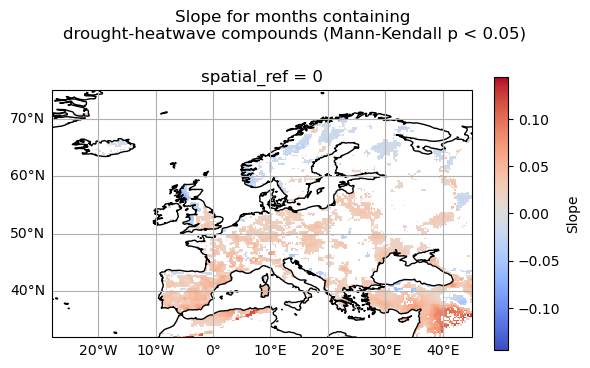

## 📋 Methodology

This notebook provides an assessment of months containing heatwave-drought compounds using **E-OBS daily gridded meteorological data for Europe from 1950 to present derived from in-situ observations dataset**, [E-OBS](https://cds.climate.copernicus.eu/datasets/insitu-gridded-observations-europe?tab=overview). Months containing at least one heatwave–drought compound event are identified as those in which the 3-month Standardised Precipitation Evapotranspiration Index (SPEI-3), calculated at a monthly temporal resolution using a 1-month rolling step, falls below −1, while at least one heatwave event occurs within the same month, using the 90th percentile of the daily mean temperature (TG) as the detection threshold for excessive heat (TG90p). The latter is selected as a subcomponent of the Excess Heat Factor (EHF) index. Both climate indices are based on the recommendations of the World Meteorological Organization (WMO)'s Expert Team on Sector-Specific Climate Indices (ET-SCI), in conjunction with sector experts.

The assessment examines the occurrence and temporal trends of these compound-event months using the Mann–Kendall trend test and Sen’s slope estimator.

The analysis and results follow the next outline:

**[](code-section-1)**
- **[](code-section-1.1)**
- **[](code-section-1.2)**
- **[](code-section-1.3)**
- **[](code-section-1.4)**


**[](code-section-2)**
- **[](code-section-2.1)**
- **[](code-section-2.2)**
- **[](code-section-2.3)**
- **[](code-section-2.4)**

**[](code-section-3)**

**[](code-section-4)**

**[](code-section-5)**


## 📈 Analysis and results

(code-section-1)= 
### 1. Define the Area of Interest (AoI), search and download E-OBS

(code-section-1.1)= 
#### 1.1 Import the required packages

We will be working with data in NetCDF format. To best handle this data, we will use libraries for working with multidimensional arrays, particularly Xarray. We will also need libraries for plotting and viewing data; in this case we will use Matplotlib and Cartopy.

In [1]:
import math
import tempfile

import numpy as np
import xarray as xr
from c3s_eqc_automatic_quality_control import download
from scipy.stats import gamma, norm
import pooch
import matplotlib.pyplot as plt
from shapely.geometry import mapping
import cartopy.crs as ccrs
import rioxarray
import geopandas as gpd
import pymannkendall as mk
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


(code-section-1.2)= 
#### 1.2 Data Overview 

To search for data, visit the CDS website: http://cds.climate.copernicus.eu Here you can search for 'in-situ observations' using the search bar. The data we need for this tutorial is the E-OBS daily gridded meteorological data for Europe from 1950 to present, derived from in-situ observations. This catalogue entry provides a daily gridded dataset of historical meteorological observations, covering Europe (land-only), from 1950 to the present. This data is derived from in-situ meteorological stations, made available through the European Climate Assessment & Dataset (ECA&D) project, as provided by National Meteorological and Hydrological Services (NMHSs) and other data-holding institutes. 
E-OBS comprises a set of spatially continuous Essential Climate Variables (ECVs) from the Surface Atmosphere, following the Global Climate Observing System (GCOS) convention, provided as the mean and spread of the spatial prediction ensemble algorithm, at regular latitude-longitude grid intervals (at a 0.1° and 0.25° spatial resolution), and covering a long time period, from 1 January 1950 to the present day. In addition to the land surface elevation, E-OBS includes daily air temperature (mean, maximum and minimum), precipitation amount, wind speed, sea-level pressure and shortwave downwelling radiation. 
The E-OBS version used for this Use Case, E-OBSv31.0e, was released in September 2024 and its main difference from the previous E-OBSv30.0e is the inclusion of new series.
Having selected the correct dataset, we now need to specify what product type, variables, and temporal and geographic coverage we are interested in. In this Use Case, the ensemble mean of daily mean temperature and Precipitation amount will be used, considering the last version available (31.0e). These can all be selected in the “Download data” tab from the CDS. In this tab, a form appears in which we will select the following parameters to download, for example:

- Product Type: Ensemble mean
- Variables: daily precipitation sum, and mean temperature
- Grid resolution: 0.25
- Period: Full period
- Version: 31.0e
- Format: Zip file (.zip)

At the end of the download form, select `Show API request`. This will reveal a block of code, which you can simply copy and paste into a cell of your Jupyter Notebook …





(code-section-1.3)= 
#### 1.3. Download and prepare E-OBS data

… having copied the API request to a Jupyter Notebook cell, running it will retrieve and download the data you requested into your local directory. However, before you run it, the terms and conditions of this particular dataset need to have been accepted directly at the CDS website. The option to view and accept these conditions is given at the end of the download form, just above the Show API request option. In addition, it is also useful to define the time period and Area of Interest (AoI) parameters and edit the request accordingly, as exemplified in the cells below.

In [2]:
collection_id = "insitu-gridded-observations-europe"
request = {
    "format": "zip",
    "product_type": "ensemble_mean",
    "variable": ["mean_temperature", "precipitation_amount"],
    "grid_resolution": "0_25deg",
    "period": "full_period",
    "version": "31_0e"
}

(code-section-1.4)= 
#### 1.4 Download biogeographical regions shapefile

To better illustrate the spatial patterns of compound heatwave-drought events over Europe, it is useful to use spatial aggregation units for our analysis. Here, we will be using the Biogeographical Regions in Europe. This dataset contains the official delineations used in the Habitats Directive (92/43/EEC) and for the EMERALD Network set up under the Convention on the Conservation of European Wildlife and Natural Habitats (Bern Convention), and the dataset is provided by the European Environmental Agency, available here: https://www.eea.europa.eu/en/analysis/maps-and-charts/biogeographical-regions-in-europe-2

In [3]:
url = "https://sdi.eea.europa.eu/datashare/s/ib6gcwyyFmwFnfL/download"
files = pooch.retrieve(
    url=url,
    known_hash=None,
    fname="biogeo_regions.zip",
    processor=pooch.Unzip(extract_dir="biogeo_regions")
)

print(files)

['/data/wp5/.cache/pooch/biogeo_regions/eea_v_3035_1_mio_biogeo-regions_p_2016_v01_r00/BiogeoRegions2016.prj', '/data/wp5/.cache/pooch/biogeo_regions/eea_v_3035_1_mio_biogeo-regions_p_2016_v01_r00/BiogeoRegions2016.shp', '/data/wp5/.cache/pooch/biogeo_regions/eea_v_3035_1_mio_biogeo-regions_p_2016_v01_r00/README.md', '/data/wp5/.cache/pooch/biogeo_regions/eea_v_3035_1_mio_biogeo-regions_p_2016_v01_r00/Biogeographical_regions_Europe_2016_ver_1_metadata_c6d27566-e699-4d58-a132-bbe3fe01491b.xml', '/data/wp5/.cache/pooch/biogeo_regions/eea_v_3035_1_mio_biogeo-regions_p_2016_v01_r00/BiogeoRegions2016.sqlite', '/data/wp5/.cache/pooch/biogeo_regions/eea_v_3035_1_mio_biogeo-regions_p_2016_v01_r00/BiogeoRegions2016.dbf', '/data/wp5/.cache/pooch/biogeo_regions/eea_v_3035_1_mio_biogeo-regions_p_2016_v01_r00/BiogeoRegions2016.shx', '/data/wp5/.cache/pooch/biogeo_regions/eea_v_3035_1_mio_biogeo-regions_p_2016_v01_r00/BiogeoRegions2016.cpg']


Befor proceeding with the analysis, it's useful to inspect the Biogeographical Regions dataset in terms of existing classes and their spatial distribution.

In [4]:
# Open shapefile

# Select the shapefile
shp_file = [f for f in files if f.endswith(".shp")][0]
biogeoregions = gpd.read_file(shp_file)
biogeoregions = biogeoregions.to_crs("EPSG:4326")

biogeoregions

,PK_UID,short_name,pre_2012,code,name,geometry
0,1,alpine,ALP,Alpine,Alpine Bio-geographical Region,"MULTIPOLYGON (((13.95511 42.15849, 13.97267 42..."
1,2,anatolian,ANA,Anatolian,Anatolian Bio-geographical Region,"POLYGON ((44.23502 41.00345, 44.29092 40.95563..."
2,3,arctic,ARC,Arctic,Arctic Bio-geographical Region,"MULTIPOLYGON (((-14.15531 64.59547, -14.16376 ..."
3,4,atlantic,ATL,Atlantic,Atlantic Bio-geographical Region,"MULTIPOLYGON (((-7.91327 51.9073, -7.91331 51...."
4,5,blackSea,BLS,BlackSea,Black Sea Bio-geographical Region,"MULTIPOLYGON (((31.68171 41.40784, 31.67965 41..."
5,6,boreal,BOR,Boreal,Boreal Bio-geographical Region,"MULTIPOLYGON (((15.96006 56.17099, 15.96028 56..."
6,7,continental,CON,Continental,Continental Bio-geographical Region,"MULTIPOLYGON (((11.68926 54.66394, 11.6891 54...."
7,8,macaronesia,MAC,Macaronesia,Macaronesian Bio-geographical Region,"MULTIPOLYGON (((-15.36375 27.9894, -15.36341 2..."
8,9,mediterranean,MED,Mediterranean,Mediterranean Bio-geographical Region,"MULTIPOLYGON (((12.52998 35.52716, 12.53124 35..."
9,10,outside,OUT,Outside,outside Europe,"MULTIPOLYGON (((10.83582 33.89309, 10.87423 33..."


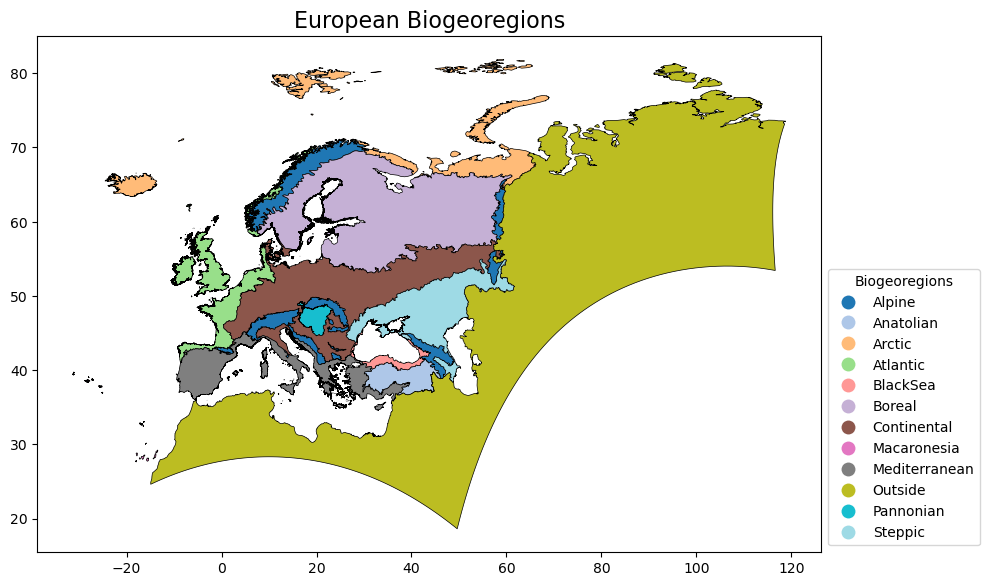

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

biogeoregions.plot(
    column="code",
    categorical=True,
    cmap="tab20",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    legend_kwds={
        "title": "Biogeoregions",
        "loc": "lower left",
        "bbox_to_anchor": (1, 0)  # move legend outside
    },
    ax=ax
)

ax.set_title("European Biogeoregions", fontsize=16)

plt.tight_layout()
plt.show()

In [6]:
# Remove outside, macaronesia because we have no E-OBS data there
biogeoregions = biogeoregions[~biogeoregions["short_name"].isin(["outside", "macaronesia"])].copy()

(code-section-2)= 
### 2. Identify months containing compound events


Now we can identify our months containing at least one compound event. In this analysis, compound events are defined as months during which drought conditions coincide (based on SPEI) with the occurrence of at least one heatwave (based on TG90p) event. Although identifying compound events at the monthly scale is a limitation, this approach was necessary because the drought and heatwave algorithms operate over different temporal scopes. Therefore, using different assumptions regarding the temporal scale of extremes may lead to different results, and care should be taken when interpreting them.


For this, we first identify drought and heatwave conditions.

(code-section-2.1)= 
#### 2.1 Calculate Standardised Precipitation Evapotranspiration Index (SPEI)

The SPEI index incorporates temperature data to account for both precipitation and evapotranspiration (ET), making it sensitive to climate-driven changes in water demand. This allows SPEI to better reflect drought conditions under warming scenarios, as it considers not only rainfall deficits but also increased evaporation due to higher temperatures. While several ET estimation algorithms exist, here we use the Thornthwaite method, which is based on temperature and solar radiation, by latitude and season. The functions for Evapotranspiration computation were based on the "climate_indices" Python library, from James Adams [[2]](https://github.com/monocongo/climate_indices).

SPEI index requires the definition of the time scale for aggregating the variables and calculate its values as seasonal or annual summaries (e.g., 3 months, 6 months, 1 year). Here we are going to select 3 months as the target time, and proceed to calculate the precipitation and evapotranspiration sums over this period with a 1-month rolling window to obtain the index calculated for every month (i.e., based on that month and the prior two).

In [7]:
def compute_mean_daylight_hours(da):
    da = da.convert_calendar("noleap", dim="time")
    dayofyear = da["time"].dt.dayofyear
    solar_declination = 0.409 * np.sin((2 * math.pi / 365) * dayofyear - 1.39)

    latitude = np.deg2rad(da["latitude"])
    sunset_hour_angle = -np.tan(latitude) * np.tan(solar_declination)
    sunset_hour_angle = xr.where(sunset_hour_angle < -1, -1, sunset_hour_angle)
    sunset_hour_angle = xr.where(sunset_hour_angle > 1, 1, sunset_hour_angle)

    daylight_hours = (24 / math.pi) * np.acos(sunset_hour_angle)
    daylight_hours = daylight_hours.resample(time="1MS").mean()
    return daylight_hours.convert_calendar("gregorian", dim="time")


def compute_monthly_pet(da):
    mean_monthly_temps = da.resample(time="1MS").mean()
    mean_monthly_temps = xr.where(mean_monthly_temps < 0, 0, mean_monthly_temps)
    heat_index = np.power(mean_monthly_temps / 5, 1.514).sum("time", skipna=False)
    a = (
        (6.75e-07 * heat_index**3)
        - (7.71e-05 * heat_index**2)
        + (1.792e-02 * heat_index)
        + 0.49239
    )

    mean_daylight_hours = da.groupby("time.year").map(compute_mean_daylight_hours)
    days_in_month = mean_daylight_hours["time"].dt.days_in_month
    days_in_month = xr.where(days_in_month == 29, 28, days_in_month)
    adjust = (mean_daylight_hours / 12) * (days_in_month / 30)
    return 16 * adjust * ((10 * mean_monthly_temps / heat_index) ** a)


def apply_thornthwaite(ds):
    return ds["tg"].groupby("time.year").map(compute_monthly_pet).fillna(0)


def _calc_spei(precip):
    count_nonzero_non_nan = np.sum((precip != 0) & ~np.isnan(precip))
    if count_nonzero_non_nan < 3:
        return np.full_like(precip, np.nan)

    precip = np.array(precip)
    shape, loc, scale = gamma.fit(precip)
    gamma_dist = gamma(shape, loc=loc, scale=scale)
    cdf = gamma_dist.cdf(precip)
    return norm.ppf(cdf)


def _add_chunksizes(da):
    chunksizes = []
    for dim, size in da.sizes.items():
        match dim:
            case "time":
                size = 120
            case "latitude" | "longitude":
                size = 30
        chunksizes.append(size)
    da.encoding["chunksizes"] = tuple(chunksizes)
    return da


def compute_spei(ds, n_days):
    pet = apply_thornthwaite(ds)
    precip = ds["rr"].resample(time="1MS").sum()
    p_minus_pet = (precip - pet).chunk(time=-1, latitude=30, longitude=30)
    scaled = p_minus_pet.rolling(time=n_days, min_periods=1).sum()

    spei = xr.apply_ufunc(
        _calc_spei,
        scaled,
        input_core_dims=[["time"]],
        output_core_dims=[["time"]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk": True},
        output_dtypes=[float],
        keep_attrs=True,
    )
    spei = spei.where(np.isfinite(spei))
    spei = spei.drop_attrs()
    return _add_chunksizes(spei).to_dataset(name="spei")



(code-section-2.2)= 
### 2.2 Calculate Heatwaves 

Several heatwave definitions exist, adopting different thresholds and formulations, and based on different daily air temperature statistics (e.g., TG, TN or TX). As mentioned earlier, here, heatwaves are defined as periods during which TG exceeds the 90th percentile of a climatological baseline for at least three consecutive days. This approach is loosely based on the Excess Heat Factors (EHF)'s Excess Heat Index Significance (EHIsig) component, which measures how hot the current day is compared to a long-term reference [[3]](https://doi.org/10.3390/ijerph120100227) [[4]](https://doi.org/10.3390/ijerph15112494). While the EHF multiplies this component with the short-term Excess Heat Acclimatization (EHIaccl) counterpart, for a heatwave to be detected, the EHIsig is the primary condition, while ensuring 3-days as the minimum duration of the excess.

The percentile threshold is calculated for each calendar day based on a reference period, allowing the definition to adapt to local climate conditions. To reduce short-term variability and ensure temporal consistency, the 90th percentile climatological threshold is smoothed using a 7-day moving average (sliding window).


For this analysis, we want to identify if there is at least one heatwave event in each month.

In [8]:
def compute_p90_tg(ds, time_slice, window):
    pad = window // 2
    da = ds["tg"]
    p90 = (
        da.sel(time=time_slice)
        .groupby("time.dayofyear")
        .quantile(0.9, dim="time", method="nearest")
        .pad(dayofyear=pad, mode="wrap")
        .rolling(dayofyear=window, center=True)
        .mean()
        .isel(dayofyear=slice(pad, -pad))
    )
    p90 = p90.drop_attrs()
    return _add_chunksizes(p90).to_dataset(name="p90_tg")


def compute_heatwaves(ds, time_slice, window, n_days):
    clim = compute_p90_tg(ds, time_slice, window)["p90_tg"]
    hw = ds["tg"].groupby("time.dayofyear") > clim
    with tempfile.TemporaryDirectory(suffix=".zarr") as tmpzarr:
        hw.chunk(time=-1, latitude=30, longitude=30).to_zarr(tmpzarr)
        hw = xr.open_dataarray(tmpzarr, chunks={})
        hw = hw.rolling(time=n_days, min_periods=n_days).sum() == n_days
        hw = hw.resample(time="MS").max()
        hw = hw.drop_attrs()
        return _add_chunksizes(hw).to_dataset(name="hw").compute()


(code-section-2.3)= 
### 2.3 Identify heatwave-drought compounds

Having identified heatwave and droughts we can now define our months containing at least one compound event. 


In [9]:
def compute_compound(ds, time_slice, window, n_days):
    mask = ds["tg"].notnull().resample(time="MS").all()
    spei = compute_spei(ds, n_days)
    hw = compute_heatwaves(ds, time_slice, window, n_days)
    ds = xr.merge([spei, hw])
    ds["compound"] = (ds["hw"] > 0) & (ds["spei"] < -1)
    ds = ds.where(mask)
    for da in ds.data_vars.values():
        _add_chunksizes(da)
    return ds


def select_time_slice(ds, time_slice):
    ds = ds.sel(time=time_slice)
    for da in ds.data_vars.values():
        _add_chunksizes(da)
    return ds

In [10]:
kwargs = {
    "time_slice": slice("1961-01-01", "1990-12-31"),
    "window": 15
}

ds_compound = download.download_and_transform(
    collection_id,
    request,
    transform_func=compute_compound,
    transform_func_kwargs=kwargs | {"n_days": 3},
)

100%|██████████| 1/1 [00:01<00:00,  1.00s/it]


In [11]:
ds_compound

<xarray.Dataset> Size: 2GB
Dimensions:    (latitude: 201, longitude: 464, time: 900)
Coordinates:
  * latitude   (latitude) float64 2kB 25.38 25.62 25.88 ... 74.88 75.12 75.38
  * longitude  (longitude) float64 4kB -40.38 -40.12 -39.88 ... 75.12 75.38
  * time       (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2024-12-01
Data variables:
    spei       (latitude, longitude, time) float64 672MB dask.array<chunksize=(30, 30, 120), meta=np.ndarray>
    hw         (time, latitude, longitude) float64 672MB dask.array<chunksize=(120, 30, 30), meta=np.ndarray>
    compound   (time, latitude, longitude) float64 672MB dask.array<chunksize=(120, 30, 30), meta=np.ndarray>

As the area of the pixels varies in latitude, a weighted approach is needed when calculating area-based statistics. Let's then create weights to use later

In [12]:
weights = np.cos(np.deg2rad(ds_compound.latitude))
weights.name = "weights"

(code-section-2.4)= 
#### 2.4 Example for the year 2020

To illustrate the concept of a compound month, we can plot the time series for 2020 of the variables averaged over the AoI. 

Please note that, to ensure consistency between the time series, heatwaves here illustrated derive from the difference between the spatially weighted average air temperature and TG90p time series. Compound events derive form the intersection of these and the spatial mean of SPEI.

In [13]:
ds_2020 = download.download_and_transform(
    collection_id,
    request,
    transform_func=select_time_slice,
    transform_func_kwargs={"time_slice": slice("2020", "2020")},
)
p90_tg = download.download_and_transform(
    collection_id,
    request,
    transform_func=compute_p90_tg,
    transform_func_kwargs=kwargs,
)["p90_tg"]
ds_2020["p90_tg"] = xr.zeros_like(ds_2020["tg"]).groupby("time.dayofyear") + p90_tg

100%|██████████| 1/1 [00:00<00:00, 25.23it/s]


In [14]:
# Prepare data to be plotted - make sure they have the same spatial dimensions and CRS to cut the data by each region
ds_2020 = ds_2020.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
p90_tg = p90_tg.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
ds_compound = ds_compound.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")

ds_2020 = ds_2020.rio.write_crs("EPSG:4326")
p90_tg = p90_tg.rio.write_crs("EPSG:4326")
ds_compound = ds_compound.rio.write_crs("EPSG:4326")


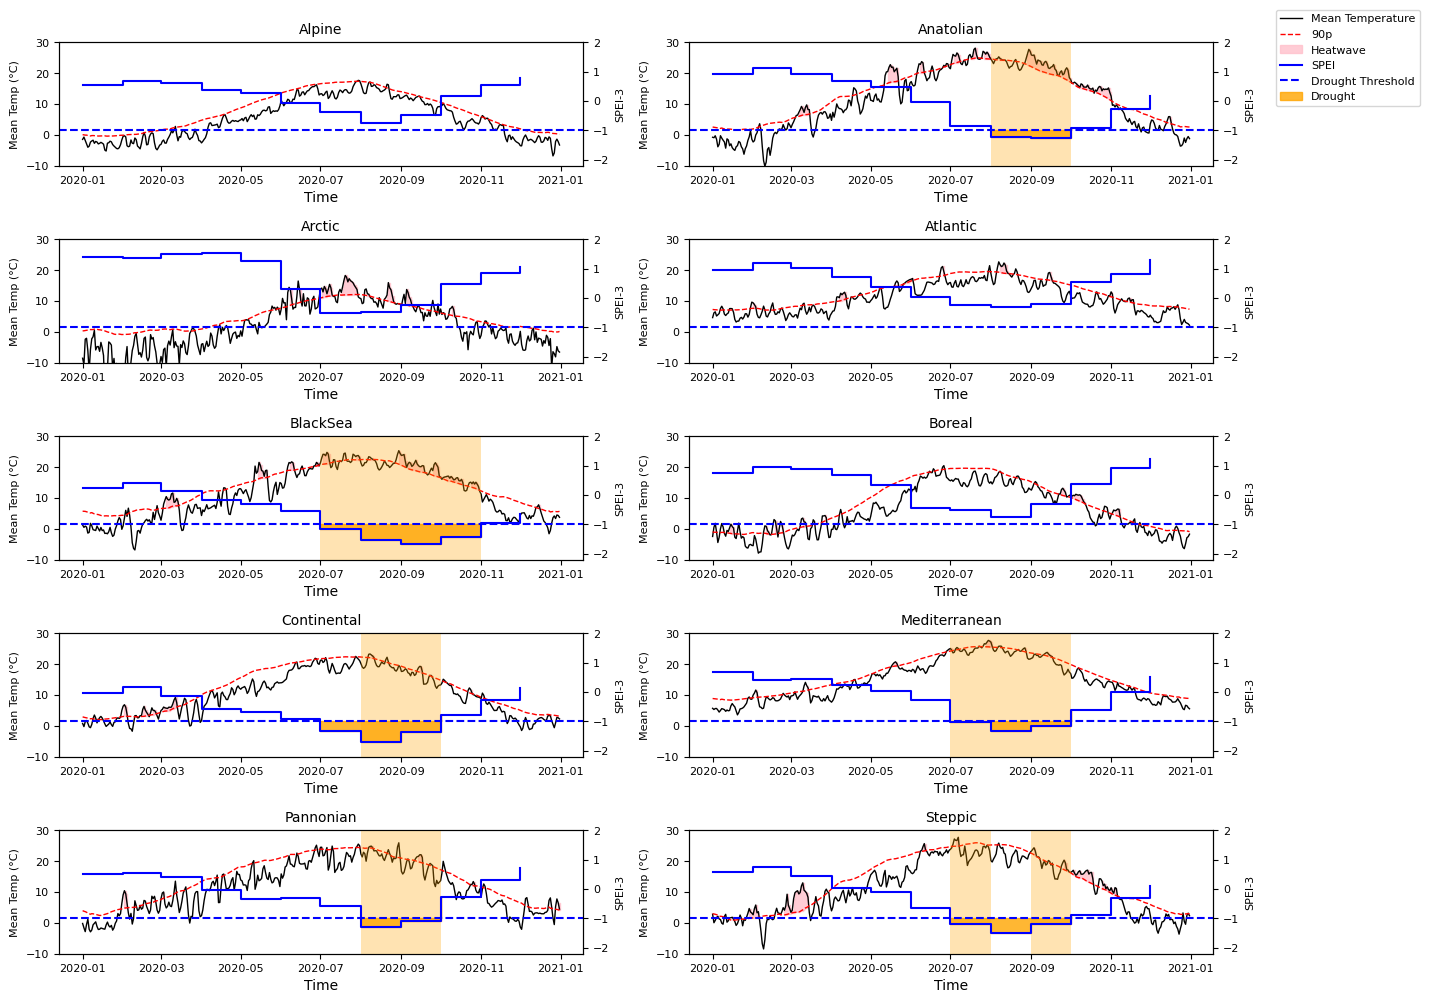

In [15]:
fig, axes = plt.subplots(5, 2, figsize=(15, 10), sharex=False)
axes = axes.flatten()

all_lines = []
all_labels = []

for ax, (idx, row) in zip(axes, biogeoregions.iterrows()):

    region = biogeoregions.loc[[idx]].copy()
    region["geometry"] = region.geometry.buffer(0)

    # Clip data by region
    tg_clip = ds_2020["tg"].rio.clip(
        region.geometry.apply(mapping),
        region.crs,
        drop=True
    )

    p90_clip = ds_2020["p90_tg"].rio.clip(
        region.geometry.apply(mapping),
        region.crs,
        drop=True
    )

    spei_clip = ds_compound["spei"].rio.clip(
        region.geometry.apply(mapping),
        region.crs,
        drop=True

    )

    # Regional weighted means
    tg_mean = tg_clip.weighted(weights).mean(
        dim=["latitude", "longitude"]
    )

    p90_mean = p90_clip.weighted(weights).mean(
        dim=["latitude", "longitude"]
    )

    spei_mean = (
        spei_clip
        .weighted(weights)
        .mean(dim=["latitude", "longitude"])
        .sel(time=slice("2020-01-01", "2020-12-31"))
    )

    # Heatwaves
    extreme_heat_days = tg_mean > p90_mean

    hw_daily = (
        extreme_heat_days
        .rolling(time=3, min_periods=3)
        .sum() >= 3
    ).fillna(False)

    hw_monthly = hw_daily.resample(time="MS").max()

   
    # Align SPEI to month-start
    spei_monthly = spei_mean.resample(time="MS").mean()

    # Compound events
    compound_monthly = (hw_monthly > 0) & (spei_monthly < -1)

    # Plot temperature and p90
    ax.plot(
        tg_mean["time"],
        tg_mean,
        label="Mean Temperature",
        color="black",
        linewidth=1
    )

    ax.plot(
        p90_mean["time"],
        p90_mean,
        label="90p",
        color="red",
        linestyle="--",
        linewidth=1
    )

    ax.fill_between(
        tg_mean["time"],
        p90_mean,
        tg_mean,
        where=hw_daily.compute().values,
        step="post",
        color="pink",
        alpha=0.8,
        label="Heatwave"
    )

    ax.set_title(row.code, fontsize=10)
    ax.set_xlabel("Time")
    ax.set_ylim(-10,30)
    ax.set_ylabel("Mean Temp (°C)", fontsize=8)
    ax.tick_params(axis="both", labelsize=8)

    # Plot SPEI
    ax2 = ax.twinx()

    ax2.plot(
        spei_monthly["time"],
        spei_monthly,
        label="SPEI",
        color="blue",
        linestyle="-",
        drawstyle="steps-post"
    )

    ax2.axhline(
        y=-1,
        color="blue",
        linestyle="--",
        label="Drought Threshold"
    )

    drought_mask = spei_monthly < -1
    drought_mask = drought_mask | drought_mask.shift(time=1, fill_value=False)

    ax2.fill_between(
        spei_monthly["time"],
        -1,
        spei_monthly,
        where=drought_mask.compute().values,
        step="post",
        color="orange",
        alpha=0.8,
        label="Drought"
    )

    ax2.set_ylabel("SPEI-3", fontsize=8)
    ax2.set_ylim(-2.2, 2)
    ax2.tick_params(axis="y", labelsize=8)

    # Shade full compound events
    compound_values = compound_monthly.compute().values
    compound_times = pd.to_datetime(compound_monthly["time"].values)

    epsilon = pd.Timedelta(seconds=1)

    for i, t in enumerate(compound_times[compound_values]):
        start = pd.Timestamp(t)
        end = start + pd.offsets.MonthBegin(1) - epsilon

        ax2.axvspan(
            start,
            end,
            ymin=0,
            ymax=1,
            color="orange",
            alpha=0.3,
            linewidth=0,
            edgecolor="none",
            label="Compound month" if i == 0 else None
        )


    # Collect legend once
    if not all_lines:
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()

        all_lines = lines1 + lines2
        all_labels = labels1 + labels2


# Hide unused axes
for ax in axes[len(biogeoregions):]:
    ax.set_visible(False)


fig.legend(
    all_lines,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.85, 0.95),
    fontsize=8
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()
plt.close(fig)

The figure shows regional variability in the occurrence and duration of heatwave-drought compounds, with Mediterranean, Steppic, Pannonian, Continental, Black Sea and Anatolian regions exhibiting compound heatwave-drought conditions during the summer and early autumn of 2020. In contrast, Alpine, Arctic, Atlantic and Boreal regions show no months with compound events during 2020.

(code-section-3)= 
### 3. Heatwave-drought compound statistics

Now, we are going to compute some statistics of the compound events at the pixel scale. We are going to start by calculating mean, sum and standard deviation of number of compound events over the climatological periods, as per the guidelines from the World Meteorological Organization (WMO) [[5]](https://library.wmo.int/idurl/4/55797):
- 1951-1980
- 1961-1990
- 1971-2000
- 1981-2010
- 1991-2020

After that, we are going to plot the years with the overall highest and lowest number of compound events over the whole european domain.

In [16]:
periods = [
    ('1951', '1980'),
    ('1961', '1990'),
    ('1971', '2000'),
    ('1981', '2010'),
    ('1991', '2020')
]

# Helper function to plot the statistics maps
def compute_stats(data, stats):
    # Calculate the mean data for each period
    stats_data_clim = []
    for start, end in periods:
        if stats == 'sum':
            stats_data = data.sel(year=slice(start, end)).sum(dim='year', skipna=False)
        elif stats == 'mean':
            stats_data = data.sel(year=slice(start, end)).mean(dim='year', skipna=False)
        elif stats == 'std':
            stats_data = data.sel(year=slice(start, end)).std(dim='year', skipna=False)
        stats_data_clim.append(stats_data)
    return stats_data_clim

def plot_stats(data, subtitle, cb_label, **kwargs):
    # Create subplots
    fig, axes = plt.subplots(nrows=1, ncols=len(periods), figsize=(24, 5), subplot_kw={"projection": ccrs.PlateCarree()})

    # Plot each clim
    for i, (ax, subdata, (start, end)) in enumerate(zip(axes, data, periods)):
        lon_min, lon_max = np.min(subdata.longitude), np.max(subdata.longitude)
        lat_min, lat_max = np.min(subdata.latitude), np.max(subdata.latitude)

        facet = subdata.plot.pcolormesh(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap='viridis',  # You can change the colormap
            add_colorbar=False,  # Disable the colorbar for now, we will add it later
            **kwargs,
        )

        # Set extent, add coastlines, and gridlines
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        ax.coastlines(lw=1)
        gl = ax.gridlines(draw_labels=True)
        ax.set_xlim(-28, 45)
        ax.set_ylim(32, 75)

        if i == 0: gl.left_labels = True
        else: gl.left_labels = False
        gl.top_labels = gl.right_labels = False
        
        # Title for each subplot
        ax.set_title(f'{subtitle} {start[:4]}-{end[:4]}')

    plt.subplots_adjust(wspace=0.05)#, right=0.85) 

    cbar_ax = fig.add_axes([0.91, 0.23, 0.01, 0.53])  # Adjust the position as needed
    cbar = fig.colorbar(facet, cax=cbar_ax, orientation='vertical')
    cbar.set_label(cb_label)

    # Show the plot
    #plt.tight_layout()
    plt.show()

In [17]:
# Count number of compound events per year
count_compound_peryear = ds_compound['compound'].groupby("time.year").sum(skipna=False)
count_compound_peryear

<xarray.DataArray 'compound' (year: 75, latitude: 201, longitude: 464)> Size: 56MB
dask.array<transpose, shape=(75, 201, 464), dtype=float64, chunksize=(10, 30, 30), chunktype=numpy.ndarray>
Coordinates:
  * year         (year) int64 600B 1950 1951 1952 1953 ... 2021 2022 2023 2024
  * latitude     (latitude) float64 2kB 25.38 25.62 25.88 ... 74.88 75.12 75.38
  * longitude    (longitude) float64 4kB -40.38 -40.12 -39.88 ... 75.12 75.38
    spatial_ref  int64 8B 0

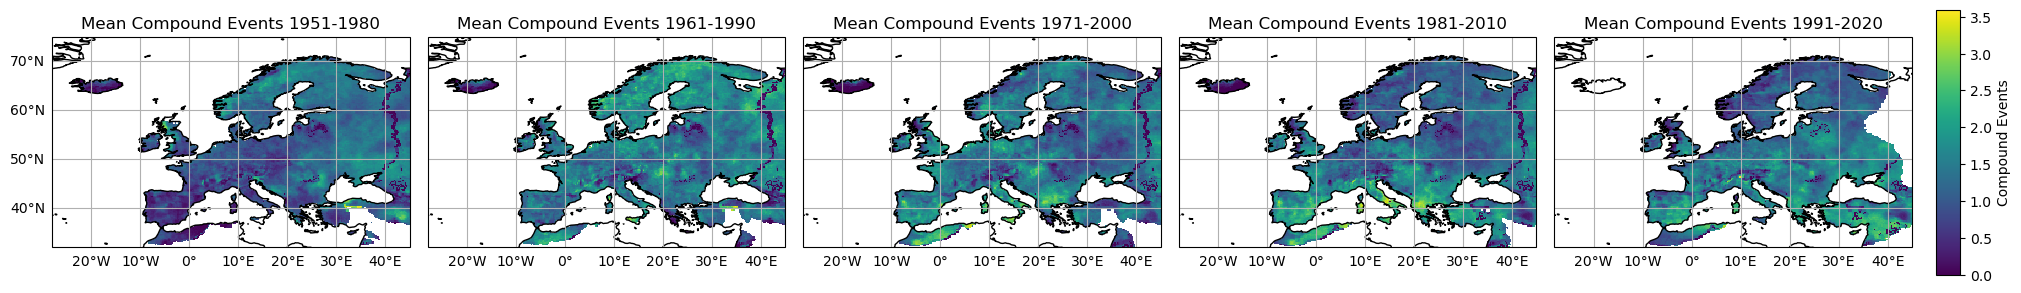

In [18]:
# Plotting mean compound events
mean_count_compound_peryear = compute_stats(count_compound_peryear, 'mean')
plot_stats(mean_count_compound_peryear, subtitle='Mean Compound Events', cb_label='Compound Events')

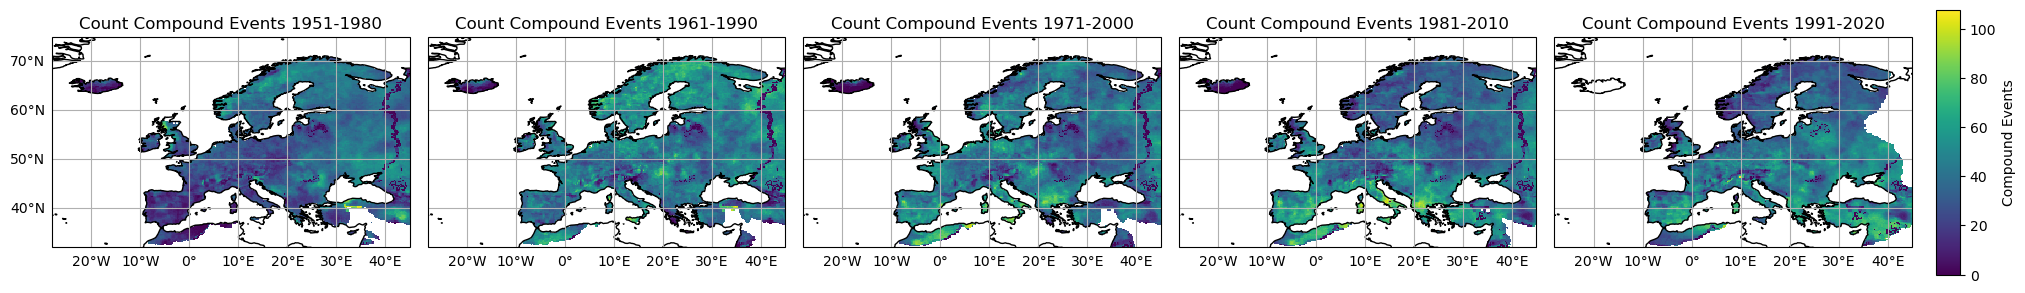

In [19]:
# Plotting count compound events
count_count_compound_peryear = compute_stats(count_compound_peryear, 'sum')
plot_stats(count_count_compound_peryear, subtitle='Count Compound Events', cb_label='Compound Events')

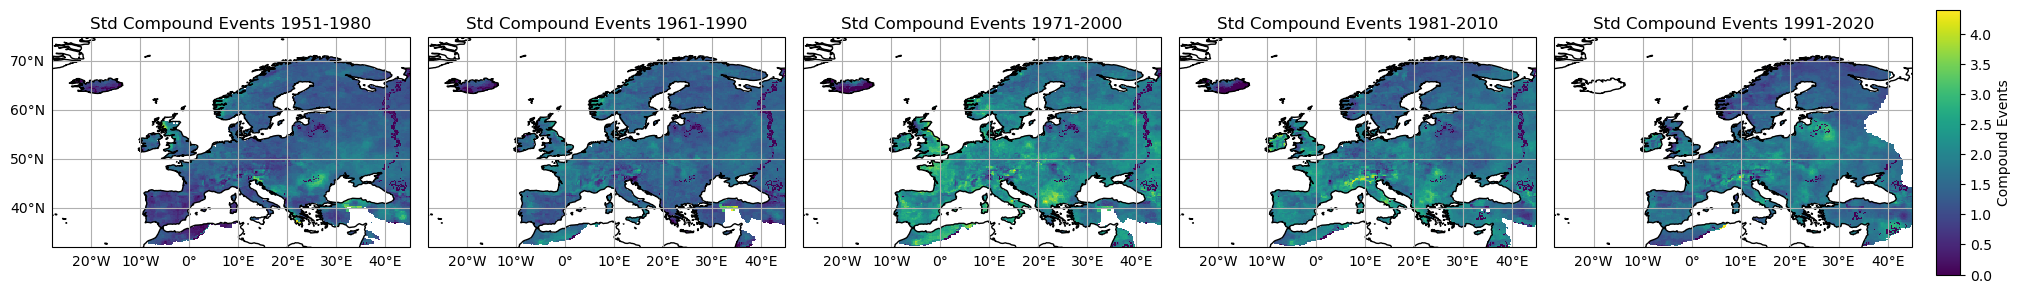

In [20]:
# Plotting std compound events
std_count_compound_peryear = compute_stats(count_compound_peryear, 'std')
plot_stats(std_count_compound_peryear, subtitle='Std Compound Events', cb_label='Compound Events')

Taken together, these figures indicate that months containing heatwave-drought compound events are not only becoming more frequent across Europe, but are also exhibiting greater variability (as measured through the standard deviation). Spatial differences are also noticeable, with the Mediterranean and Continental regions emerging as hotspots of these events. Let's now complement by looking into the year that revealed the maximum and minimum counts of compound events.

In [21]:
# Calculate the total area of compound events per year
count_compound_area_peryear = count_compound_peryear.weighted(weights).sum(dim=["latitude", "longitude"]) 
count_compound_area_peryear

<xarray.DataArray 'compound' (year: 75)> Size: 600B
dask.array<sum-aggregate, shape=(75,), dtype=float64, chunksize=(10,), chunktype=numpy.ndarray>
Coordinates:
  * year         (year) int64 600B 1950 1951 1952 1953 ... 2021 2022 2023 2024
    spatial_ref  int64 8B 0

In [22]:
# Identify the year with the maximum and minimum count of compound events
count_compound_area_peryear = count_compound_area_peryear.chunk({"year": -1}) 
year_max_compound = count_compound_area_peryear.idxmax("year").values 
year_min_compound = count_compound_area_peryear.idxmin("year").values 
year_max_compound, year_min_compound

(array(2019.), array(1978.))

In [23]:
def plot_maps(da1, da2, **kwargs): 

    # Decide how many panels n = 1 if da2 is None else 2 
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6),
                            subplot_kw={'projection': ccrs.PlateCarree()} ) 
    # Make axes always indexable
    axes = np.atleast_1d(axes) 
    datasets = [da1] if da2 is None else [da1, da2] 


    for i, da in enumerate(datasets): 
        lon_min = float(da.longitude.min()) 
        lon_max = float(da.longitude.max()) 
        lat_min = float(da.latitude.min()) 
        lat_max = float(da.latitude.max()) 
        
        da.plot.pcolormesh(
            ax=axes[i],
            transform=ccrs.PlateCarree(),
            **kwargs 
            ) 
        
        axes[i].set_extent([lon_min, lon_max, lat_min, lat_max],
                            crs=ccrs.PlateCarree()) 
        
        axes[i].coastlines(lw=1) 
        gl = axes[i].gridlines(draw_labels=True) 
        gl.top_labels = False 
        gl.right_labels = False 
        axes[i].set_xlim(-28, 45)
        axes[i].set_ylim(32, 75)

        
        plt.tight_layout() 
        
    return fig, axes

(<Figure size 1200x600 with 4 Axes>,
 array([<GeoAxes: title={'center': 'spatial_ref = 0, year = 1978'}, xlabel='longitude', ylabel='latitude'>,
        <GeoAxes: title={'center': 'spatial_ref = 0, year = 2019'}, xlabel='longitude', ylabel='latitude'>],
       dtype=object))

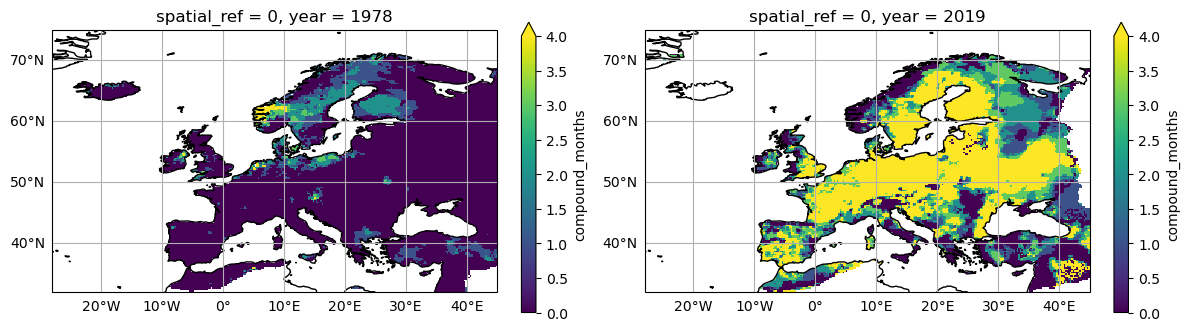

In [24]:
plot_maps(
    count_compound_peryear.sel(year=year_min_compound),
    count_compound_peryear.sel(year=year_max_compound),
    vmin=0,
    vmax=4,
    cbar_kwargs={"label": "compound_months", "fraction": 0.03}
)

- Year with the lowest number of months containing compounds over the AoI: 1978
- Year with the highest number of months containing compounds over the AoI: 2019

(code-section-4)= 
### 4. Linear Trends

To finalise the analysis, we are going to plot the trends of the number of months with at least one compound per year on a pixel-wise basis, as well as the percentage of area with compound events in each year by biogeographical region.

In [25]:
periods = [
    ("1961", "1990"),
    ("1991", "2020"),
]


def apply_mk_sen(df, column):
    np.float = np.float64  # compatibility workaround if needed
    mk_result = mk.original_test(df[column])
    sen_slope = mk.sens_slope(df[column]).slope
    return mk_result, sen_slope

def compute_period_statistics(data, periods, spatial_dims=("latitude", "longitude")):
    data = data.astype(float)
    rows = []

    for start, end in periods:
        subset = data.sel(year=slice(start, end))

        stats_ds = xr.Dataset({
            "sum": subset.sum("year", skipna=True).weighted(weights).mean(dim=spatial_dims, skipna=True),
            "mean": subset.mean("year", skipna=True).weighted(weights).mean(dim=spatial_dims, skipna=True),
            "min": subset.min("year", skipna=True).weighted(weights).mean(dim=spatial_dims, skipna=True),
            "max": subset.max("year", skipna=True).weighted(weights).mean(dim=spatial_dims, skipna=True),
            "std": subset.std("year", skipna=True).weighted(weights).mean(dim=spatial_dims, skipna=True),
        }).compute()

        rows.append({
            "period": f"{start}-{end}",
            "sum": stats_ds["sum"].item(),
            "mean": stats_ds["mean"].item(),
            "min": stats_ds["min"].item(),
            "max": stats_ds["max"].item(),
            "std": stats_ds["std"].item(),
        })

    return pd.DataFrame(rows)


def add_sen_slope_row(stats_df, value_columns=None):
    if value_columns is None:
        value_columns = ["sum", "mean", "min", "max", "std"]

    slope_row = {"period": "trend (Sen's slope)"}

    for col in value_columns:
        df_tmp = stats_df[[col]].dropna().copy()

        if len(df_tmp) < 2:
            slope_row[col] = np.nan
        else:
            mk_result, sen_slope = apply_mk_sen(df_tmp, col)
            slope_row[col] = sen_slope

    return pd.concat([stats_df, pd.DataFrame([slope_row])], ignore_index=True)


def build_big_table_by_region(
    data,
    biogeoregions,
    periods,
    region_name_col,
    spatial_dims=("latitude", "longitude"),
    target_crs="EPSG:4326"
):
    tables = []

    data = data.rio.write_crs(target_crs)

    for idx, row in biogeoregions.iterrows():
        region_name = row[region_name_col]
        region = biogeoregions.loc[[idx]].copy()
        region["geometry"] = region.geometry.buffer(0)

        try:
            clipped = data.rio.clip(
                region.geometry.apply(mapping),
                region.crs,
                drop=True
            )

            stats_df = compute_period_statistics(
                clipped,
                periods,
                spatial_dims=spatial_dims
            )

            stats_df = add_sen_slope_row(stats_df)

            stats_df["region"] = region_name
            tables.append(stats_df)

        except Exception as e:
            print(f"Skipping region {region_name}: {e}")

    if not tables:
        return pd.DataFrame(
            columns=["sum", "mean", "min", "max", "std"]
        )

    final_df = pd.concat(tables, ignore_index=True)

    final_df = (
        final_df
        .set_index(["region", "period"])
        .sort_index()
        .round(2)
    )

    return final_df


final_stats_table = build_big_table_by_region(
    data=count_compound_peryear,
    biogeoregions=biogeoregions,
    periods=periods,
    region_name_col="short_name",  
    spatial_dims=("latitude", "longitude"),
    target_crs="EPSG:4326"
)

final_stats_table

sum  mean  min   max   std
region        period                                           
alpine        1961-1990             1.25  0.76  0.0  4.08  1.12
              1991-2020             1.78  1.08  0.0  5.34  1.49
              trend (Sen's slope)   0.53  0.32  0.0  1.26  0.37
anatolian     1961-1990            10.60  0.64  0.0  3.33  0.94
              1991-2020            26.48  1.54  0.0  4.34  1.36
              trend (Sen's slope)  15.89  0.90  0.0  1.02  0.42
arctic        1961-1990             0.43  0.44  0.0  2.51  0.68
              1991-2020             0.49  0.53  0.0  2.81  0.79
              trend (Sen's slope)   0.06  0.09  0.0  0.30  0.11
atlantic      1961-1990             3.08  0.78  0.0  4.90  1.32
              1991-2020             4.62  1.17  0.0  5.55  1.58
              trend (Sen's slope)   1.55  0.39  0.0  0.65  0.26
blackSea      1961-1990             2.87  0.58  0.0  3.35  0.91
              1991-2020             7.14  1.43  0.0  5.34  1.60
              trend (Sen's slope)   4.27  0.85  0.0  1.99  0.69
boreal        1961-1990            10.03  0.85  0.0  3.60  1.04
              1991-2020            13.15  1.13  0.0  4.62  1.36
              trend (Sen's slope)   3.12  0.28  0.0  1.03  0.32
continental   1961-1990             6.27  0.75  0.0  4.09  1.17
              1991-2020            12.36  1.48  0.0  6.05  1.76
              trend (Sen's slope)   6.08  0.73  0.0  1.96  0.59
mediterranean 1961-1990             4.60  0.68  0.0  3.58  1.01
              1991-2020            12.31  1.80  0.0  5.58  1.64
              trend (Sen's slope)   7.71  1.12  0.0  2.00  0.63
pannonian     1961-1990            15.29  0.97  0.0  3.96  1.20
              1991-2020            24.71  1.56  0.0  6.67  1.76
              trend (Sen's slope)   9.41  0.59  0.0  2.70  0.56
steppic       1961-1990             3.29  0.80  0.0  3.77  1.08
              1991-2020             6.66  1.63  0.0  4.69  1.47
              trend (Sen's slope)   3.38  0.84  0.0  0.92  0.39

In [26]:
# Calculate the number of compound events per year
n_compound_events = ds_compound['compound'].resample(time='YS').sum()
n_compound_events

<xarray.DataArray 'compound' (time: 75, latitude: 201, longitude: 464)> Size: 56MB
dask.array<transpose, shape=(75, 201, 464), dtype=float64, chunksize=(10, 30, 30), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 600B 1950-01-01 1951-01-01 ... 2024-01-01
  * latitude     (latitude) float64 2kB 25.38 25.62 25.88 ... 74.88 75.12 75.38
  * longitude    (longitude) float64 4kB -40.38 -40.12 -39.88 ... 75.12 75.38
    spatial_ref  int64 8B 0

In [27]:
# Helper function to calculate trend and significance
def calculate_trend_and_significance(data_array):
    # Ensure the input array is a DataArray
    if not isinstance(data_array, xr.DataArray):
        raise ValueError("Input must be an xarray DataArray")

    # Rechunk the time dimension to a single chunk
    data_array = data_array.chunk({"time": -1})

    # Get the time dimension name
    time_dim = 'time'

    # Calculate the slope using np.polyfit
    def polyfit_slope(y):
        x = np.arange(len(y))
        return np.polyfit(x, y, 1)[0]

    slope = xr.apply_ufunc(
        polyfit_slope,
        data_array,
        vectorize=True,
        input_core_dims=[[time_dim]],
        dask="parallelized",
        output_dtypes=[float]
    )

    # Apply Mann-Kendall test
    def mann_kendall_p(x):
        return mk.original_test(x).p

    significance = xr.apply_ufunc(
        mann_kendall_p,
        data_array,
        vectorize=True,
        input_core_dims=[[time_dim]],
        dask="parallelized",
        output_dtypes=[float]
    )
    return slope, significance

In [28]:
def plot_maps(da1, da2=None, **kwargs):
    # Set up the number of subplots depending on whether one or two datasets are passed
    if da2 is None:
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 6), subplot_kw={'projection': ccrs.PlateCarree()})
        axes = [ax]
        datasets = [da1]
    else:
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})
        datasets = [da1, da2]
    
    for i, da in enumerate(datasets):
        # Get longitude and latitude extents
        lon_min, lon_max = np.min(da.longitude), np.max(da.longitude)
        lat_min, lat_max = np.min(da.latitude), np.max(da.latitude)

        # Plot using PlateCarree projection on the given axis
        facet = da.plot.pcolormesh(
            ax=axes[i],  # Use the current axis
            transform=ccrs.PlateCarree(),  # Coordinate transform for plotting
            **kwargs
        )

        # Set extent, add coastlines, and gridlines
        axes[i].set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        axes[i].coastlines(lw=1)
        axes[i].set_xlim(-28, 45)
        axes[i].set_ylim(32, 75)
        gl = axes[i].gridlines(draw_labels=True)
        gl.top_labels = gl.right_labels = False

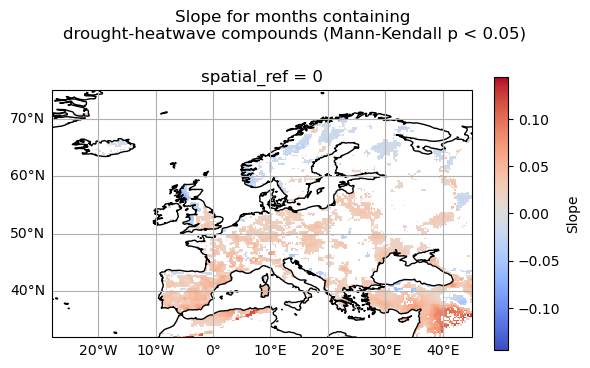

In [29]:
# Calculate the slope and significance per pixel
slope_n_compound_events, significance_n_compound_events = calculate_trend_and_significance(n_compound_events)

# Keep only statistically significant pixels
alpha = 0.05
significant_slope = slope_n_compound_events.where(significance_n_compound_events < alpha)

# Plot only significant slopes
plot_maps(
    significant_slope,
    cmap="coolwarm",
    cbar_kwargs={"fraction": 0.03, "label": "Slope"}
)

plt.suptitle(
    f"Slope for months containing \ndrought-heatwave compounds (Mann-Kendall p < {alpha})",
    y=0.8
)

plt.tight_layout()
plt.show()
plt.close()

The results reveal that the increase in compound heatwave-drought occurrence is not spatially uniform across Europe. Significant positive trends dominate large parts of southern, western, and central Europe. Increases are particularly visible across the Iberian Peninsula, southern France, some regions of Italy, the Balkans, and portions of eastern Europe. When positive changes are detected, their magnitudes are mostly on the order of 0.5 additional months containing compound events per decade. In contrast, negative trends are more localised and mainly appear in northern and north-eastern Europe, as well as isolated regions near the eastern Mediterranean and Black Sea. However, these decreasing trends are spatially limited compared with the widespread positive trends observed elsewhere, and their magnitudes are much lower. 

The use of the Mann–Kendall significance test ensures that only statistically robust trends are shown, reducing the influence of short-term variability.

In [30]:
# Function to apply Mann-Kendall and Sen's Slope for a specifi column of a dataframe df
def apply_mk_sen(df, column):
    np.float = np.float64
    mk_result = mk.original_test(df[column])
    sen_slope = mk.sens_slope(df[column]).slope
    return mk_result, sen_slope

# Calculate the adjusted intercept - this is for visualization purposes
def calculate_adjusted_intercept(intercept, slope, start_year):
    return intercept - slope * start_year



def compute_region_yearly_counts(data, spatial_dims=("latitude", "longitude"), value_name="count"):

    # valid-data mask
    valid_mask = data.notnull()

    # weighted affected area
    weighted_affected = (
        data.where(valid_mask) * weights
    ).sum(dim=["latitude", "longitude"], skipna=True)

    # weighted total valid area
    weighted_total = (
        weights.where(valid_mask)
    ).sum(dim=["latitude", "longitude"], skipna=True)

    # percentage of affected area
    percentage_per_year = (weighted_affected / weighted_total) * 100

    mean_percentage_area_peryear = (
        percentage_per_year.groupby("time.year").mean()
    )

    df = (
        mean_percentage_area_peryear
        .to_dataframe(name=value_name)
        .reset_index()
        .rename(columns={"year": "Year"})
    )

    df = df.dropna(subset=[value_name]).copy()
    df["Year"] = df["Year"].astype(int)

    return df


def build_region_yearly_dataframe(
    data,
    biogeoregions,
    region_name_col,
    spatial_dims=("latitude", "longitude"),
    target_crs="EPSG:4326",
    value_name="count"
):
    all_regions = []

    data = data.rio.write_crs(target_crs)

    for idx, row in biogeoregions.iterrows():
        region = biogeoregions.loc[[idx]].copy()
        region["geometry"] = region.geometry.buffer(0)

        region_name = row[region_name_col]

        try:
            clipped = data.rio.clip(
                region.geometry.apply(mapping),
                region.crs,
                drop=True
            )

            df_region = compute_region_yearly_counts(
                clipped,
                spatial_dims=spatial_dims,
                value_name=value_name
            )

            df_region["region"] = region_name
            all_regions.append(df_region)

        except Exception as e:
            print(f"Skipping region {region_name}: {e}")



    if len(all_regions) == 0:
        return pd.DataFrame(columns=["Year", value_name, "region"])

    final_df = pd.concat(all_regions, ignore_index=True)
    return final_df


def plot_mk_sen_subplots_by_region(
    region_df,
    value_col,
    region_col="region",
    year_col="Year",
    ncols=2,
    figsize_per_subplot=(5, 3),
    sharex=True,
    sharey=False,
    title = "Mann-Kendall and Sen's Slope: Count of Compound Drought-Heatwave Months by Region"
):
    regions = sorted(region_df[region_col].dropna().unique())
    n_regions = len(regions)

    if n_regions == 0:
        print("No regions available to plot.")
        return

    nrows = math.ceil(n_regions / ncols)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_subplot[0] * ncols, figsize_per_subplot[1] * nrows),
        sharex=sharex,
        sharey=sharey
    )

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])

    axes_flat = axes.flatten()

    for i, region_name in enumerate(regions):
        ax = axes_flat[i]

        df_reg = (
            region_df[region_df[region_col] == region_name]
            .sort_values(year_col)
            .dropna(subset=[value_col])
            .copy()
        )

        if len(df_reg) == 0:
            ax.set_visible(False)
            continue

        try:
            mk_result, sen_slope = apply_mk_sen(df_reg, value_col)

            start_year = df_reg[year_col].min()
            adjusted_intercept = calculate_adjusted_intercept(
                mk_result.intercept,
                sen_slope,
                start_year
            )

            ax.bar(df_reg[year_col], df_reg[value_col], color="black", label="Count")
            ax.plot(
                df_reg[year_col],
                sen_slope * df_reg[year_col] + adjusted_intercept,
                linestyle="--",
                color="red",
                label="Sen's slope"
            )

            ax.set_title(str(region_name), fontsize=10)
            ax.set_xlabel("Year")
            ax.set_ylabel("mean monthly \ncompound-affected area (%)", fontsize=10)
            ax.set_ylim(0,55)

            ax.text(
                0.03, 0.97,
                f"Slope: {sen_slope:.3f}\n"
                f"P-value: {mk_result.p:.3f}\n"
                f"Tau: {mk_result.Tau:.3f}",
                transform=ax.transAxes,
                verticalalignment="top",
                fontsize=8,
                color="red",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
            )

        except Exception as e:
            ax.text(
                0.5, 0.5,
                f"Error\n{region_name}\n{e}",
                ha="center",
                va="center",
                transform=ax.transAxes
            )
            ax.set_title(str(region_name), fontsize=10)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    handles, labels = axes_flat[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1))
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close()


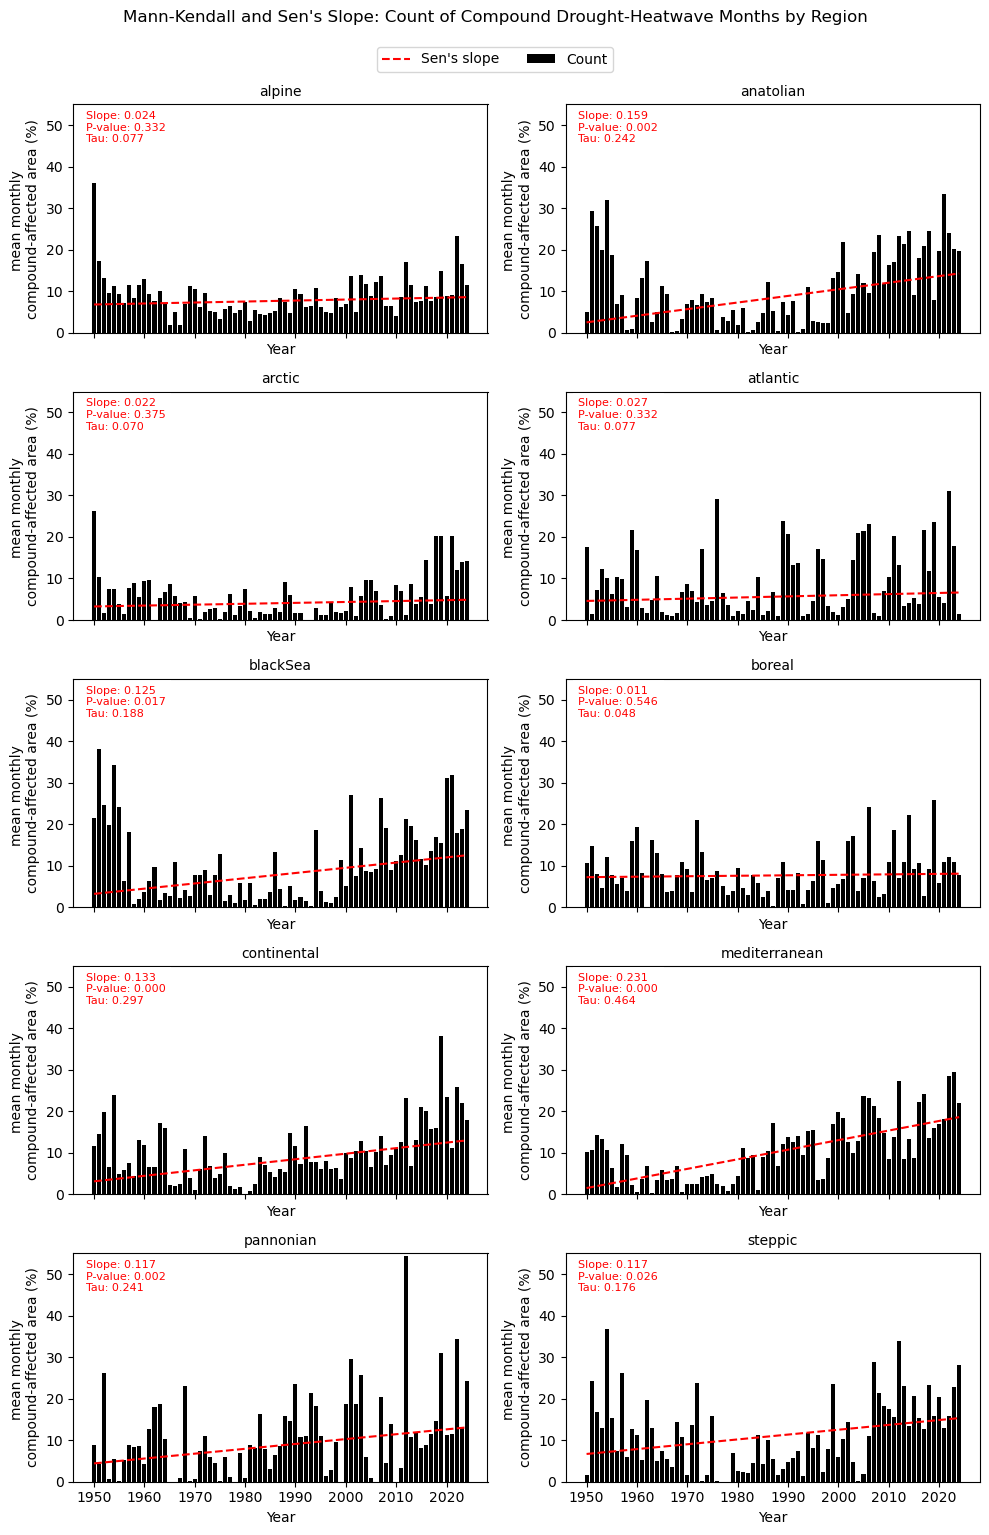

In [31]:
# Create a new dataframe with the year and the count of compound events
count_compound_regions_df = build_region_yearly_dataframe(
    data=ds_compound['compound'],
    biogeoregions=biogeoregions,
    region_name_col="short_name",  
    spatial_dims=("latitude", "longitude"),
    target_crs="EPSG:4326",
    value_name="count_compound_area"
)

plot_mk_sen_subplots_by_region(
    region_df=count_compound_regions_df,
    value_col="count_compound_area",
    region_col="region",
    year_col="Year",
    ncols=2,
    figsize_per_subplot=(5, 3),
    sharex=True,
    sharey=False,
    title = "Mann-Kendall and Sen's Slope: Count of Compound Drought-Heatwave Months by Region"
)

Trends of the area percentage of months containing at least one compound event also varies between the regions, with overall increases identified. 

The strongest and most statistically significant increases are observed in the Mediterranean, Continental, Anatolian, Pannonian, Black Sea, and Steppic regions. Among these, the Mediterranean region shows the largest Sen’s slope (0.231) and the highest Kendall’s Tau (0.464), indicating a strong and persistent increase in the spatial extent of compound events over time. Similarly, Continental and Anatolian regions exhibit pronounced upward trends with highly significant p-values, suggesting that concurrent hot and dry conditions are becoming increasingly widespread in these climates.

The Black Sea, Pannonian, and Steppic regions also display significant positive trends, although with greater interannual variability. These regions show alternating periods of low and high compound occurrences, but the long-term tendency remains upward.

In contrast, Alpine, Arctic, Atlantic, and Boreal regions exhibit weaker and statistically non-significant trends. Although these regions still show some increase in compound-event occurrence, the lower Sen’s slope values and higher p-values suggest that long-term changes are less robust.


(code-section-5)=
### 5. Main takeaways

- The study analysed the spatial and temporal evolution of heatwave-drought compounds across Europe using E-OBS daily mean temperature data and SPEI-3 drought indicators. Compounds are defined as months in which drought conditions (SPEI-3 < −1) coincided with at least one heatwave event identified using a smoothed 90th percentile temperature threshold (TG90p). Although identifying compound events at the monthly scale is a limitation, this approach was necessary because the drought and heatwave algorithms operate over different temporal scopes. Therefore, using different assumptions regarding the temporal scale of extremes may lead to different results, and care should be taken when interpreting them.

- The results show a clear spatial gradient in compound-event occurrence across Europe. Mediterranean, Continental, Pannonian, Steppic, Black Sea, and Anatolian regions consistently exhibited the highest frequency and spatial extent of compound drought–heatwave months, while Alpine, Atlantic, Arctic, and Boreal regions generally experience fewer events.

- Trend analyses using the Mann–Kendall test and Sen’s slope demonstrate statistically significant positive trends in several European regions, especially in Mediterranean, Continental, Anatolian, Pannonian, Black Sea, and Steppic climates. In contrast, northern and maritime regions show weaker or non-significant trends, suggesting lower susceptibility to persistent compound hot–dry conditions.

- Although different studies tend to use different metrics, the spatial patterns of the results agree with previous studies using SPEI and heatwaves to assess compound events (e.g. Weynants et al. [[6]](https://doi.org/10.5194/essd-17-6621-2025) and Mathbout et al. [[7]](https://doi.org/10.1016/j.jag.2025.104987)). The E-OBS dataset proved suitable for identifying broad regional patterns and changes in compound HW-drought across Europe.

- However, as described in this dataset's documentation, the usage of this dataset should be with caution in interpreting trends and extremes, considering the potential limitations in accuracy and completeness, especially in regions with sparse observational data [[8]](https://doi.org/10.1029/2017JD028200). Furthermore, the spatial variability in stations density should be considered when interpreting results at a more localised scale. For instance, it may also be influenced by factors such as changes in observational practices, station location shifts, or urbanisation effects, which can introduce uncertainties in the interpretation of long-term trends. For local-specific analysis, the ensemble spread can serve as a proxy in determining the pixel-wise level of uncertainty.

## ℹ️ If you want to know more

### Key resources

Some key resources and further reading were linked throughout this assessment.

The CDS catalogue entries for the data used were:
* E-OBS daily gridded meteorological data for Europe from 1950 to present derived from in-situ observations:
    https://cds.climate.copernicus.eu/datasets/insitu-gridded-observations-europe?tab=overview
* ERA5 hourly data on single levels from 1940 to present: https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview 


Code libraries used:
* [C3S EQC custom functions](https://github.com/bopen/c3s-eqc-automatic-quality-control/tree/main/c3s_eqc_automatic_quality_control), `c3s_eqc_automatic_quality_control`,  prepared by [B-Open](https://www.bopen.eu/)

### References

[[1]](https://climate.copernicus.eu/esotc/2023) Copernicus Climate Change Service. 2024. European State of the Climate 2023.

[[2]](https://github.com/monocongo/climate_indices) Adams, J. (2017). Climate_indices, an open source Python library providing reference implementations of commonly used climate indices.

[[3]](https://doi.org/10.3390/ijerph120100227) Nairn, J. R., & Fawcett, R. J. B. (2015). The Excess Heat Factor: A Metric for Heatwave Intensity and Its Use in Classifying Heatwave Severity. International Journal of Environmental Research and Public Health, 12(1), 227-253. 

[[4]](https://doi.org/10.3390/ijerph15112494) Nairn, J., Ostendorf, B., & Bi, P. (2018). Performance of Excess Heat Factor Severity as a Global Heatwave Health Impact Index. International Journal of Environmental Research and Public Health, 15(11), 2494. 

[[5]](https://library.wmo.int/idurl/4/55797) World Meteorological Organization (WMO), Guidelines on the Calculation of Climate Normals.

[[6]](https://doi.org/10.5194/essd-17-6621-2025) Weynants, M., Ji, C., Linscheid, N., Weber, U., Mahecha, M. D., and Gans, F. (2025) Dheed: an ERA5 based global database of compound dry and hot extreme events from 1950 to 2023, Earth Syst. Sci. Data, 17, 6621–6645.

[[7]](https://doi.org/10.1016/j.jag.2025.104987) Mathbout, S., Boustras, G., Lopez Bustins, J. A., Martin Vide, J., & Papazoglou, P. (2025). Europe’s double threat: Evolving patterns of compound heatwaves and droughts. International Journal of Applied Earth Observation and Geoinformation, 145, 104987. 
 
[[8]](https://doi.org/10.1029/2017JD028200) Cornes, R., G. van der Schrier, E.J.M. van den Besselaar, and P.D. Jones. 2018: An Ensemble Version of the E-OBS Temperature and Precipitation Datasets, J. Geophys. Res. (Atmospheres), 123.

